# Twitch Analytics Overview

This notebook focuses on exploratory analytics and visualization for the Twitch dataset produced by the ETL pipeline.

It is intentionally separate from the ClickHouse notebook so the responsibilities are clear:
- `clickhouse_playground.ipynb` is for storage, SQL, and ClickHouse exploration
- this notebook is for descriptive analysis and charts

## 1. Install dependencies

If you open this notebook in a different environment, install at least:

```bash
pip install pandas matplotlib seaborn ipykernel
```

In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

LINE_PINK = "#bf5af2"
LINE_PINK_SOFT = "#f3ddff"
LINE_BLUE = "#5b7cff"
LINE_BLUE_SOFT = "#e2e8ff"
TIME_SERIES_PALETTE = [
    "#9147ff",
    "#c026d3",
    "#5b7cff",
    "#ec4899",
    "#7c3aed",
    "#38bdf8",
    "#a855f7",
    "#f472b6",
    "#6366f1",
    "#8b5cf6",
]

## 2. Load the processed dataset and analytics outputs

These charts use the full processed CSV produced by the pipeline and selected pre-aggregated tables from `data/analytics`.  

In [11]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_path = project_root / "data" / "processed" / "twitch_streams_enriched.csv"
analytics_dir = project_root / "data" / "analytics"

processed_df = pd.read_csv(processed_path, parse_dates=["collected_at"])
streamer_summary_df = pd.read_csv(
    analytics_dir / "streamer_summary.csv",
    parse_dates=["first_seen_at", "last_seen_at"],
)
language_hourly_summary_df = pd.read_csv(analytics_dir / "language_hourly_summary.csv")
game_hourly_summary_df = pd.read_csv(analytics_dir / "game_hourly_summary.csv")
collection_health_summary_df = pd.read_csv(
    analytics_dir / "collection_health_summary.csv",
    parse_dates=["collected_at"],
)

[
    processed_df.shape,
    streamer_summary_df.shape,
    language_hourly_summary_df.shape,
    game_hourly_summary_df.shape,
    collection_health_summary_df.shape,
]

[(93830, 37), (6008, 13), (456, 7), (5074, 7), (97, 9)]

## 3. Overall metrics

These charts summarize the whole collection period rather than only the latest snapshot.

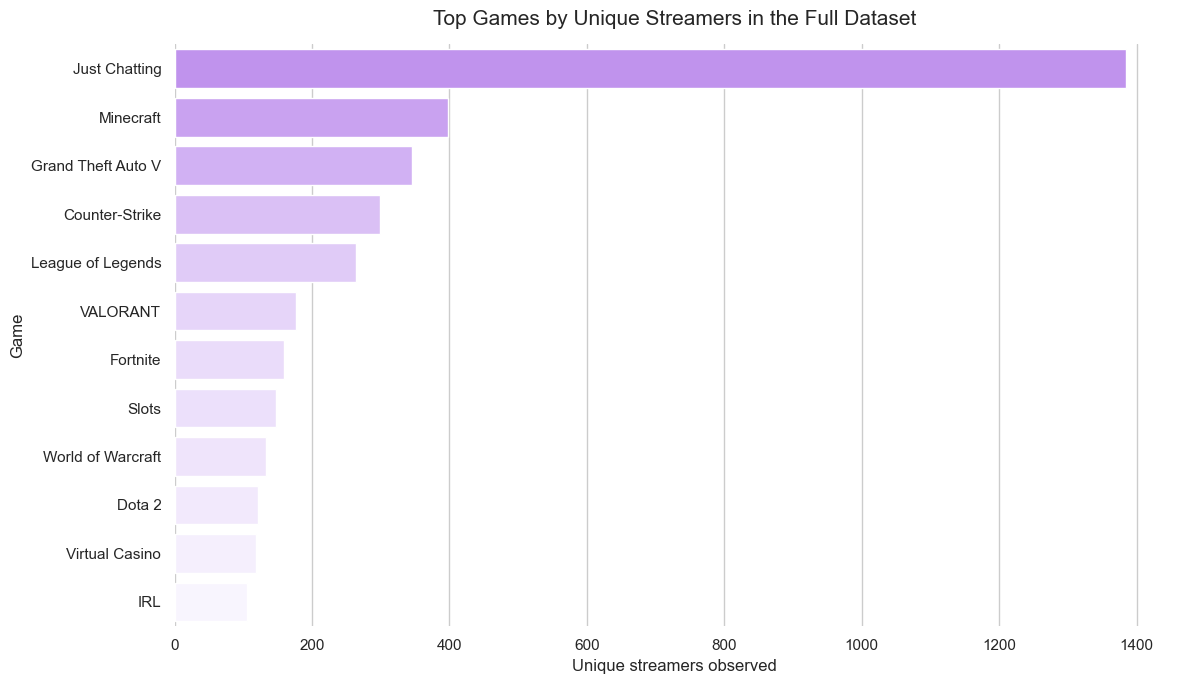

In [3]:
overall_games_df = (
    processed_df.groupby("game_name", dropna=False)
    .agg(
        unique_streamers=("user_id", "nunique"),
        peak_viewers=("viewer_count", "max"),
        avg_viewers=("viewer_count", "mean"),
    )
    .sort_values("unique_streamers", ascending=False)
    .head(12)
    .reset_index()
)
lilac_palette = sns.blend_palette(
    ["#c084fc", "#d8b4fe", "#e9d5ff", "#efe1ff", "#f8f4ff"],
    n_colors=max(len(overall_games_df), 3),
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=overall_games_df,
    x="unique_streamers",
    y="game_name",
    hue="game_name",
    palette=lilac_palette,
    legend=False,
    errorbar=None,
)

ax.set_title("Top Games by Unique Streamers in the Full Dataset", fontsize=15, pad=14)
ax.set_xlabel("Unique streamers observed")
ax.set_ylabel("Game")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

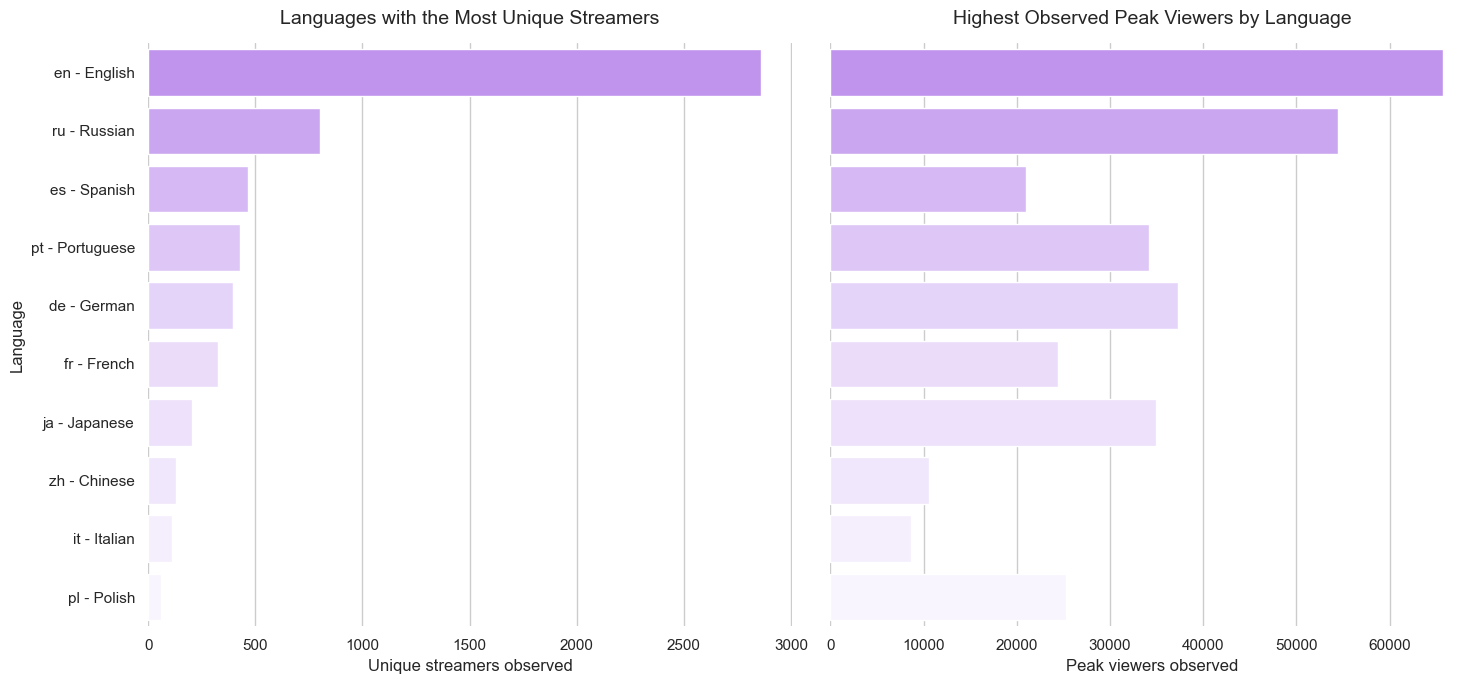

In [4]:
language_labels = {
    "en": "English",
    "es": "Spanish",
    "pt": "Portuguese",
    "de": "German",
    "fr": "French",
    "ru": "Russian",
    "ja": "Japanese",
    "ko": "Korean",
    "zh": "Chinese",
    "zh-cn": "Chinese (Simplified)",
    "zh-tw": "Chinese (Traditional)",
    "pl": "Polish",
    "sk": "Slovak",
    "cs": "Czech",
    "it": "Italian",
    "tr": "Turkish",
    "uk": "Ukrainian",
    "nl": "Dutch",
    "sv": "Swedish",
    "fi": "Finnish",
    "da": "Danish",
    "no": "Norwegian",
    "hu": "Hungarian",
    "asl": "American Sign Language",
    "el": "Greek",
}

overall_language_df = (
    processed_df.groupby("language", dropna=False)
    .agg(
        unique_streamers=("user_id", "nunique"),
        peak_viewers=("viewer_count", "max"),
    )
    .sort_values("unique_streamers", ascending=False)
    .head(10)
    .reset_index()
)
overall_language_df["language_display"] = overall_language_df["language"].apply(
    lambda language: f"{language} - {language_labels.get(language, language.title())}"
)
soft_lilac_palette = sns.blend_palette(
    ["#c084fc", "#d8b4fe", "#e9d5ff", "#efe1ff", "#f8f4ff"],
    n_colors=max(len(overall_language_df), 3),
)
language_colors = dict(
    zip(overall_language_df["language"], soft_lilac_palette[: len(overall_language_df)])
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

sns.barplot(
    data=overall_language_df,
    x="unique_streamers",
    y="language_display",
    hue="language",
    palette=language_colors,
    errorbar=None,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Languages with the Most Unique Streamers", fontsize=14, pad=14)
axes[0].set_xlabel("Unique streamers observed")
axes[0].set_ylabel("Language")

sns.barplot(
    data=overall_language_df,
    x="peak_viewers",
    y="language_display",
    hue="language",
    palette=language_colors,
    errorbar=None,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Highest Observed Peak Viewers by Language", fontsize=14, pad=14)
axes[1].set_xlabel("Peak viewers observed")
axes[1].set_ylabel("")

for axis in axes:
    sns.despine(ax=axis, left=True, bottom=True)

plt.tight_layout()
plt.show()

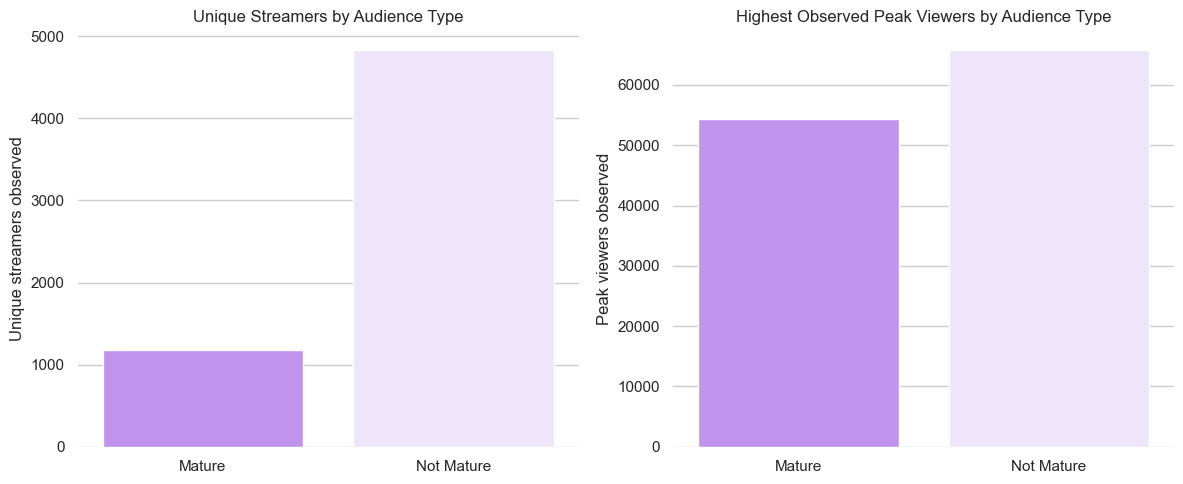

In [5]:
overall_maturity_df = (
    processed_df.assign(
        audience_type=processed_df["is_mature"].map(
            {True: "Mature", False: "Not Mature"}
        )
    )
    .groupby("audience_type", dropna=False)
    .agg(
        unique_streamers=("user_id", "nunique"),
        peak_viewers=("viewer_count", "max"),
    )
    .reset_index()
)
mature_palette = ["#c084fc", "#efe1ff"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=overall_maturity_df,
    x="audience_type",
    y="unique_streamers",
    hue="audience_type",
    palette=mature_palette,
    legend=False,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Unique Streamers by Audience Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Unique streamers observed")

sns.barplot(
    data=overall_maturity_df,
    x="audience_type",
    y="peak_viewers",
    hue="audience_type",
    palette=mature_palette,
    legend=False,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Highest Observed Peak Viewers by Audience Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Peak viewers observed")

for ax in axes:
    sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

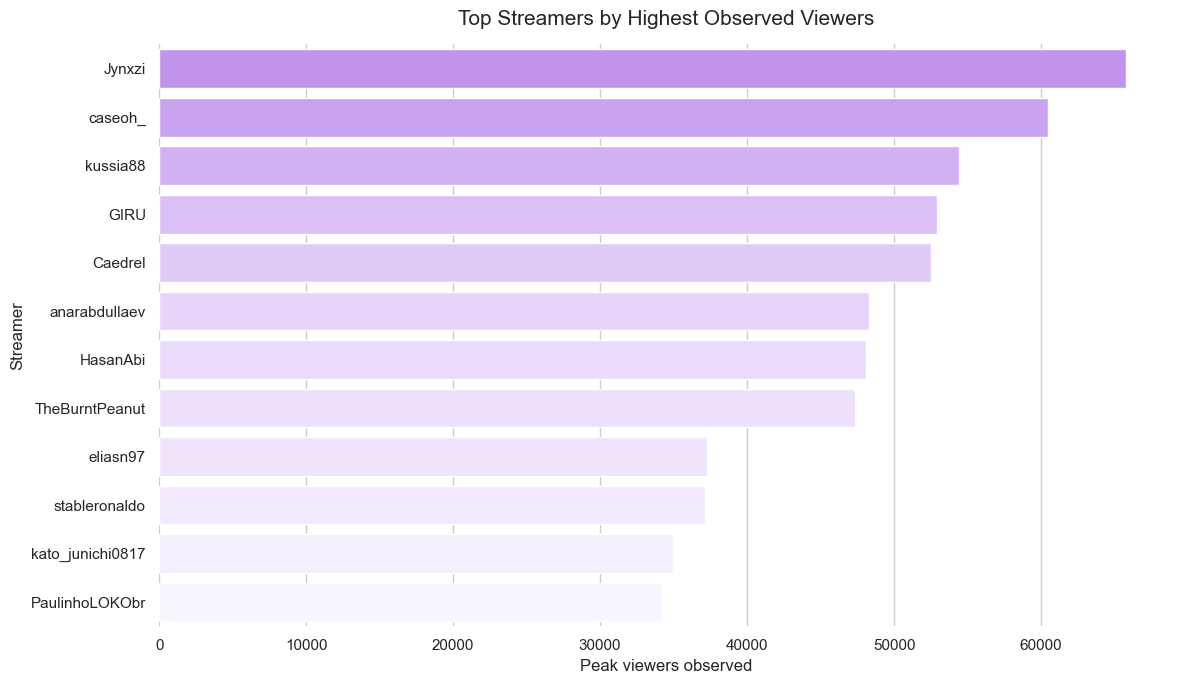

In [ ]:
top_streamers_overall_df = (
    processed_df.groupby(["user_name", "user_login"], dropna=False)
    .agg(
        peak_viewers=("viewer_count", "max"),
        avg_viewers=("viewer_count", "mean"),
        snapshots=("id", "count"),
    )
    .sort_values("peak_viewers", ascending=False)
    .head(12)
    .reset_index()
)
top_streamers_overall_df["streamer_display"] = top_streamers_overall_df.apply(
    lambda row: (
        row["user_name"] if str(row["user_name"]).isascii() else str(row["user_login"])
    ),
    axis=1,
)
fastest_palette = sns.blend_palette(
    ["#c084fc", "#d8b4fe", "#e9d5ff", "#efe1ff", "#f8f4ff"],
    n_colors=max(len(top_streamers_overall_df), 3),
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=top_streamers_overall_df,
    x="peak_viewers",
    y="streamer_display",
    hue="streamer_display",
    palette=fastest_palette,
    legend=False,
    errorbar=None,
)

ax.set_title("Top Streamers by Highest Observed Viewers", fontsize=15, pad=14)
ax.set_xlabel("Peak viewers observed")
ax.set_ylabel("Streamer")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 4. Time-based trends

These charts use repeated snapshot timestamps from the full dataset.

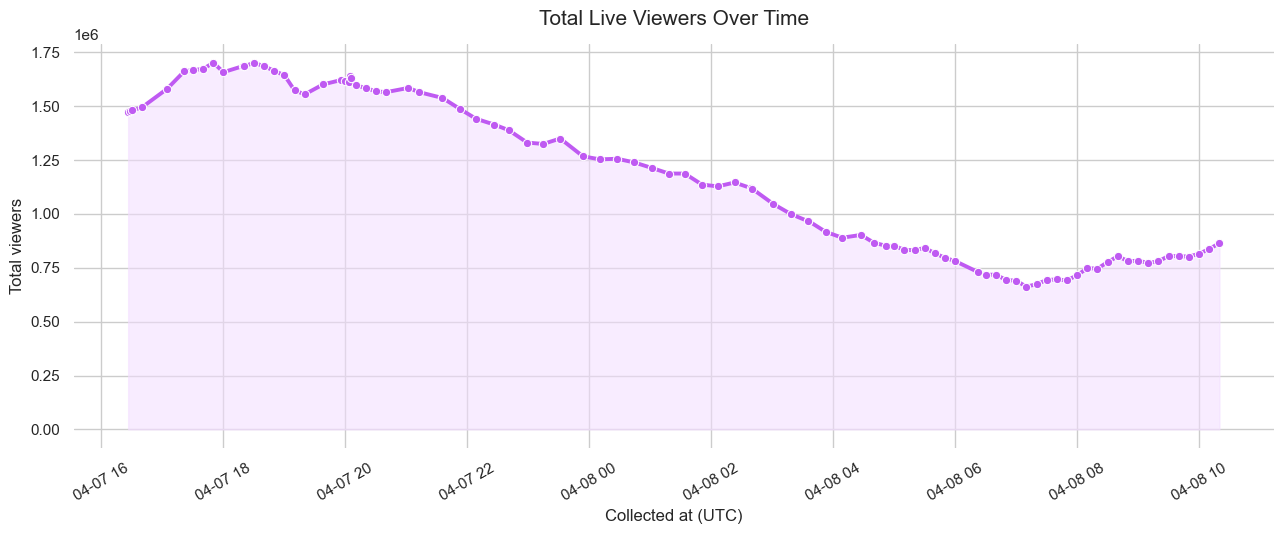

In [27]:
full_batch_threshold = 900

full_batch_timestamps = (
    processed_df.groupby("collected_at")
    .size()
    .loc[lambda counts: counts >= full_batch_threshold]
    .index
)

timeline_df = (
    processed_df[processed_df["collected_at"].isin(full_batch_timestamps)]
    .groupby("collected_at")
    .agg(total_viewers=("viewer_count", "sum"))
    .reset_index()
    .sort_values("collected_at")
)

plt.figure(figsize=(13, 5.5))
ax = sns.lineplot(
    data=timeline_df,
    x="collected_at",
    y="total_viewers",
    color=LINE_PINK,
    linewidth=2.8,
    marker="o",
)
ax.fill_between(
    timeline_df["collected_at"],
    timeline_df["total_viewers"],
    color=LINE_PINK_SOFT,
    alpha=0.55,
)
ax.set_title("Total Live Viewers Over Time", fontsize=15, pad=14)
ax.set_xlabel("Collected at (UTC)")
ax.set_ylabel("Total viewers")
sns.despine(left=True, bottom=True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

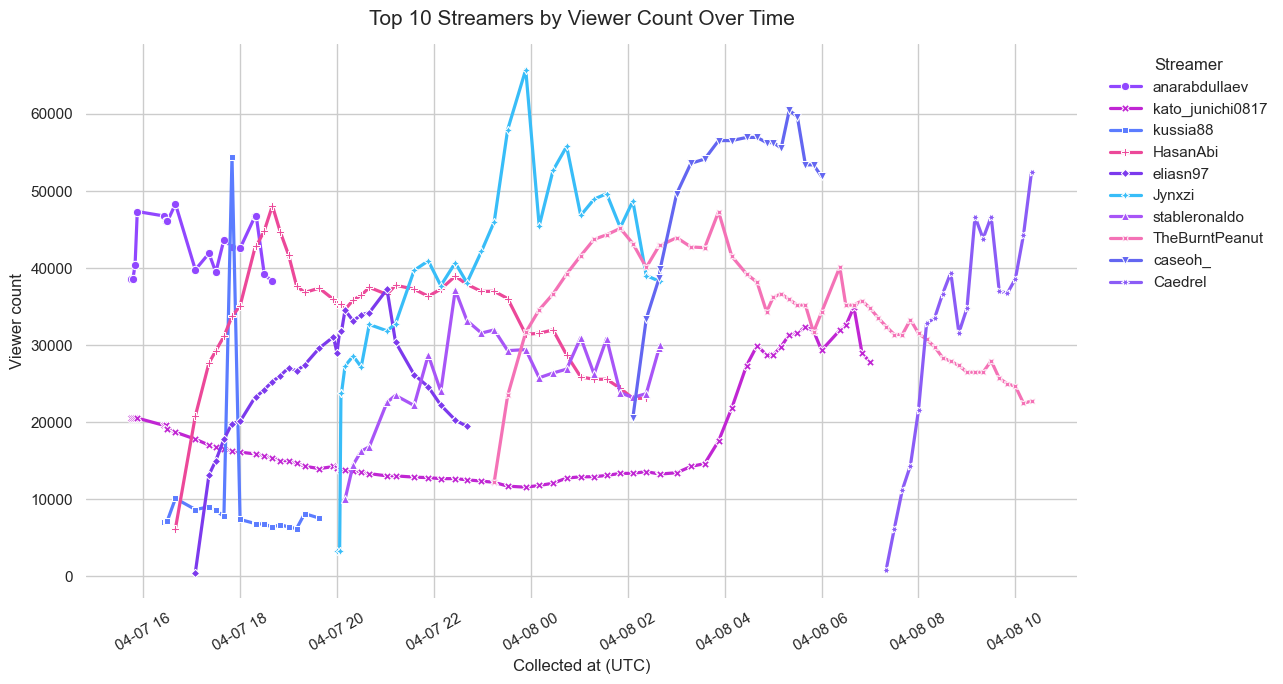

In [28]:
streamer_timeline_candidates = (
    processed_df.groupby(["user_name", "user_login"], dropna=False)
    .agg(
        peak_viewers=("viewer_count", "max"),
        snapshots=("id", "count"),
    )
    .query("snapshots >= 10")
    .sort_values(["peak_viewers", "snapshots"], ascending=False)
    .head(10)
    .reset_index()
)
streamer_timeline_candidates["streamer_display"] = streamer_timeline_candidates.apply(
    lambda row: (
        row["user_name"] if str(row["user_name"]).isascii() else str(row["user_login"])
    ),
    axis=1,
)
tracked_streamers = streamer_timeline_candidates[
    ["user_name", "streamer_display"]
].copy()

streamer_timeline_df = (
    processed_df.merge(tracked_streamers, on="user_name", how="inner")
    .groupby(["collected_at", "streamer_display"], dropna=False)
    .agg(viewer_count=("viewer_count", "max"))
    .reset_index()
    .sort_values("collected_at")
)
streamer_palette = sns.color_palette(
    TIME_SERIES_PALETTE,
    n_colors=max(len(tracked_streamers), 3),
)

plt.figure(figsize=(13, 7))
ax = sns.lineplot(
    data=streamer_timeline_df,
    x="collected_at",
    y="viewer_count",
    hue="streamer_display",
    style="streamer_display",
    markers=True,
    dashes=False,
    palette=streamer_palette,
    linewidth=2.3,
)

ax.set_title("Top 10 Streamers by Viewer Count Over Time", fontsize=15, pad=14)
ax.set_xlabel("Collected at (UTC)")
ax.set_ylabel("Viewer count")
ax.legend(title="Streamer", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(left=True, bottom=True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

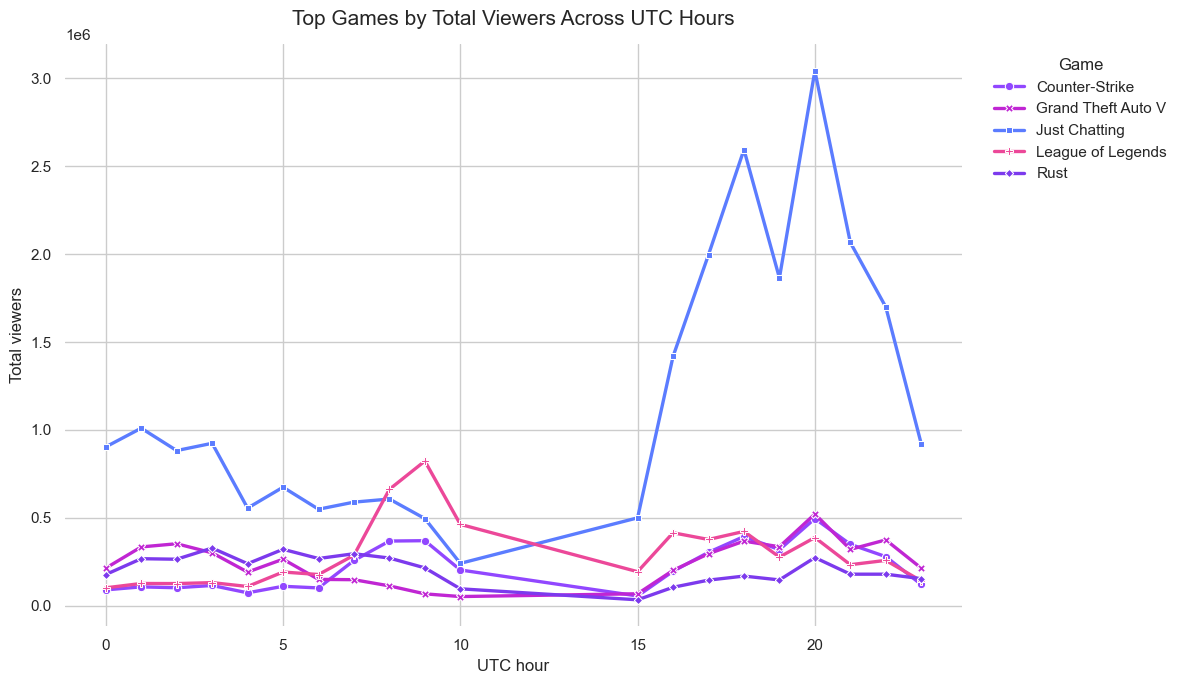

In [29]:
top_games_for_timeline = (
    game_hourly_summary_df.groupby("game_name", dropna=False)["total_viewers"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
game_hourly_plot_df = game_hourly_summary_df[
    game_hourly_summary_df["game_name"].isin(top_games_for_timeline)
].copy()
game_hourly_plot_df = game_hourly_plot_df.sort_values(
    ["snapshot_hour_utc", "game_name"]
)
game_timeline_palette = sns.color_palette(
    TIME_SERIES_PALETTE,
    n_colors=max(len(top_games_for_timeline), 3),
)

plt.figure(figsize=(12, 7))
ax = sns.lineplot(
    data=game_hourly_plot_df,
    x="snapshot_hour_utc",
    y="total_viewers",
    hue="game_name",
    style="game_name",
    markers=True,
    dashes=False,
    palette=game_timeline_palette,
    linewidth=2.4,
)

ax.set_title("Top Games by Total Viewers Across UTC Hours", fontsize=15, pad=14)
ax.set_xlabel("UTC hour")
ax.set_ylabel("Total viewers")
ax.legend(title="Game", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()